In [21]:
!pip install ultralytics mediapipe==0.10.13
print("셀 1 완료")

셀 1 완료


In [22]:
from google.colab import drive
drive.mount('/content/drive')
print("셀 2 완료")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
셀 2 완료


In [27]:
import os
import zipfile
import urllib.request
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from mediapipe.python.solutions.hands import Hands, HandLandmark, HAND_CONNECTIONS
from mediapipe.python.solutions.drawing_utils import draw_landmarks
from mediapipe.python.solutions.pose import Pose, PoseLandmark

print("✅ 임포트 완료")


print("셀 3 완료")

✅ 임포트 완료
셀 3 완료


In [28]:
# ──────────────────────────────────────────────
# Google Drive 파일 ID 입력
# ──────────────────────────────────────────────

FILE_IDS = [
    "1f3UEJ45UHqcPXY2IoPe-O7ItWVdEDpLz",  # 사이드   - 성은
    "1xwkhGSERd6yaES47ZBxtS7auDdFdVzWE",  # 오버핸드 - 용인
    "1wS_yOM378-y6JNB1-76iR5DOgrU1apSo",  # 언더     - 준선
]

DOWNLOAD_DIR = "/content/zips"
EXTRACT_DIR  = "/content/dataset"

os.makedirs(DOWNLOAD_DIR, exist_ok=True)
os.makedirs(EXTRACT_DIR,  exist_ok=True)

def gdrive_url(file_id):
    return f"https://drive.google.com/uc?export=download&id={file_id}"

def download_and_extract(file_id, download_dir, extract_dir):
    zip_path = os.path.join(download_dir, f"{file_id}.zip")
    dest     = os.path.join(extract_dir, file_id)
    print(f"[다운로드] {file_id}")
    urllib.request.urlretrieve(gdrive_url(file_id), zip_path)
    print(f"[압축 해제] → {dest}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(dest)
    return dest

extract_paths = [download_and_extract(fid, DOWNLOAD_DIR, EXTRACT_DIR) for fid in FILE_IDS]

print("셀 4 완료")


[다운로드] 1f3UEJ45UHqcPXY2IoPe-O7ItWVdEDpLz
[압축 해제] → /content/dataset/1f3UEJ45UHqcPXY2IoPe-O7ItWVdEDpLz
[다운로드] 1xwkhGSERd6yaES47ZBxtS7auDdFdVzWE
[압축 해제] → /content/dataset/1xwkhGSERd6yaES47ZBxtS7auDdFdVzWE
[다운로드] 1wS_yOM378-y6JNB1-76iR5DOgrU1apSo
[압축 해제] → /content/dataset/1wS_yOM378-y6JNB1-76iR5DOgrU1apSo
셀 4 완료


In [29]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

image_paths = sorted([
    str(p) for root in extract_paths
    for p in Path(root).rglob("*")
    if p.suffix.lower() in IMAGE_EXTS
])
print(f"총 이미지 수: {len(image_paths)}")
print("셀 5 완료")

총 이미지 수: 60
셀 5 완료


In [30]:
# ──────────────────────────────────────────────
# Pose: 전신에서 손목 위치 감지
# Hands: 손목 crop 영역에서 손가락 좌표 추출
# ──────────────────────────────────────────────

pose_detector = Pose(
    static_image_mode=True,
    model_complexity=2,
    min_detection_confidence=0.3,
)

hands_detector = Hands(
    static_image_mode=True,
    max_num_hands=2,
    min_detection_confidence=0.1,
)

LANDMARK_NAMES = [lm.name for lm in HandLandmark]
print("✅ 모델 초기화 완료")


print("셀 6 완료")

✅ 모델 초기화 완료
셀 6 완료


In [31]:
def extract_landmarks_via_pose(image_path, pose_det, hand_det, padding=0.7):
    """
    1단계: Pose로 손목 위치 감지
    2단계: 손목 기준 crop
    3단계: Hands로 손가락 랜드마크 추출
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None

    H, W = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    pose_result = pose_det.process(img_rgb)
    if not pose_result.pose_landmarks:
        return None

    lms = pose_result.pose_landmarks.landmark
    all_rows = []

    for wrist_id in [PoseLandmark.LEFT_WRIST, PoseLandmark.RIGHT_WRIST]:
        wrist = lms[wrist_id]
        if wrist.visibility < 0.3:
            continue

        cx, cy = int(wrist.x * W), int(wrist.y * H)
        pad = int(H * 0.15 * padding)
        x1, y1 = max(0, cx-pad), max(0, cy-pad)
        x2, y2 = min(W, cx+pad), min(H, cy+pad)

        crop = img_bgr[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        crop_h, crop_w = crop.shape[:2]
        crop_rgb = cv2.cvtColor(cv2.resize(crop, (256, 256)), cv2.COLOR_BGR2RGB)
        hand_result = hand_det.process(crop_rgb)
        if not hand_result.multi_hand_landmarks:
            continue

        for hand_idx, hand_lms in enumerate(hand_result.multi_hand_landmarks):
            handedness = hand_result.multi_handedness[hand_idx].classification[0].label
            for lm_idx, lm in enumerate(hand_lms.landmark):
                # crop 내 정규화 좌표 → 원본 픽셀 좌표로 역변환
                px = lm.x * crop_w + x1
                py = lm.y * crop_h + y1
                all_rows.append({
                    "image_path" : image_path,
                    "image_name" : Path(image_path).name,
                    "handedness" : handedness,
                    "landmark_id": lm_idx,
                    "landmark"   : LANDMARK_NAMES[lm_idx],
                    "x_px"       : px,   # 원본 픽셀 좌표
                    "y_px"       : py,
                    "x"          : lm.x, # crop 내 정규화 좌표
                    "y"          : lm.y,
                    "z"          : lm.z,
                })

    return all_rows if all_rows else None


print("셀 7 완료")

셀 7 완료


In [32]:
all_records = []
fail_count  = 0

for i, path in enumerate(image_paths):
    records = extract_landmarks_via_pose(path, pose_detector, hands_detector)
    if records is None:
        fail_count += 1
    else:
        all_records.extend(records)

    if (i + 1) % 20 == 0 or (i + 1) == len(image_paths):
        print(f"[{i+1}/{len(image_paths)}] 누적 랜드마크: {len(all_records)}, 실패: {fail_count}")

print(f"\n✅ 완료 — 성공: {len(image_paths)-fail_count}, 실패: {fail_count}")

print("셀 8 완료")

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


[20/60] 누적 랜드마크: 420, 실패: 4
[40/60] 누적 랜드마크: 861, 실패: 9
[60/60] 누적 랜드마크: 1302, 실패: 15

✅ 완료 — 성공: 45, 실패: 15
셀 8 완료


In [33]:
# ──────────────────────────────────────────────
# all_records → 이미지당 1행, 랜드마크별 x_px/y_px 컬럼
# 역변환된 원본 픽셀 좌표(x_px, y_px) 사용
# ──────────────────────────────────────────────

df_mp = pd.DataFrame(all_records)

df_mp_wide = df_mp.pivot_table(
    index="image_name",
    columns="landmark",
    values=["x_px", "y_px"],
    aggfunc="first"
).reset_index()

# 컬럼명 정리: (x_px, WRIST) → WRIST_x
df_mp_wide.columns = [
    col[1] + "_x" if col[0] == "x_px"
    else col[1] + "_y" if col[0] == "y_px"
    else col[0]
    for col in df_mp_wide.columns
]

print(f"MP wide shape: {df_mp_wide.shape}")
df_mp_wide.head()

print("셀 9 완료")

MP wide shape: (45, 43)
셀 9 완료


In [34]:
# ──────────────────────────────────────────────
# 라벨링 ZIP (CSV 3개 포함)
# ──────────────────────────────────────────────

LABEL_ZIP_ID  = "1X2n66SrERg0c_RS0jts07rQOqD312nlX"
LABEL_DL_DIR  = "/content/label_zip"
LABEL_EXT_DIR = "/content/labels"

os.makedirs(LABEL_DL_DIR,  exist_ok=True)
os.makedirs(LABEL_EXT_DIR, exist_ok=True)

zip_path = os.path.join(LABEL_DL_DIR, f"{LABEL_ZIP_ID}.zip")
urllib.request.urlretrieve(gdrive_url(LABEL_ZIP_ID), zip_path)
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(LABEL_EXT_DIR)

csv_paths = list(Path(LABEL_EXT_DIR).rglob("*.csv"))
print(f"발견된 CSV: {len(csv_paths)}개")

df_label = pd.concat([pd.read_csv(p) for p in csv_paths], ignore_index=True)
print(f"라벨 shape: {df_label.shape}")
df_label.head()


발견된 CSV: 3개
라벨 shape: (60, 48)


,image_id,image_name,width,height,WRIST_x,WRIST_y,THUMB_CMC_x,THUMB_CMC_y,THUMB_MCP_x,THUMB_MCP_y,...,PINKY_MCP_x,PINKY_MCP_y,PINKY_PIP_x,PINKY_PIP_y,PINKY_DIP_x,PINKY_DIP_y,PINKY_TIP_x,PINKY_TIP_y,INDEX_FINGER_TIP_2_x,INDEX_FINGER_TIP_2_y
0,0,baseball_ra_pu_d02_00767_00026.jpg,1920,1080,1050.13,675.20,NaN,NaN,1043.13,692.10,...,1060.73,693.10,NaN,NaN,NaN,NaN,1051.23,691.10,NaN,NaN
1,1,baseball_ra_pu_d02_00767_00027.jpg,1920,1080,1048.33,637.10,NaN,NaN,1044.53,650.20,...,1061.93,649.70,NaN,NaN,NaN,NaN,1059.93,650.60,NaN,NaN
2,2,baseball_ra_pu_d02_00767_00028.jpg,1920,1080,1055.33,578.80,NaN,NaN,1052.68,591.48,...,1071.80,576.80,NaN,NaN,NaN,NaN,1069.20,576.00,NaN,NaN
3,3,baseball_ra_pu_d02_00767_00029.jpg,1920,1080,1076.48,562.78,NaN,NaN,1092.08,562.98,...,1085.88,546.48,NaN,NaN,NaN,NaN,1086.98,555.28,NaN,NaN
4,4,baseball_ra_pu_d02_00767_00030.jpg,1920,1080,1077.48,557.88,NaN,NaN,1084.58,547.28,...,1080.68,543.18,NaN,NaN,NaN,NaN,1088.08,543.88,NaN,NaN


In [35]:
# ──────────────────────────────────────────────
# image_name 기준 병합 후 랜드마크별 유클리드 거리 계산
# ──────────────────────────────────────────────

# MP 컬럼에 _mp 접미사
rename_map = {col: f"{col}_mp" for col in df_mp_wide.columns if col != "image_name"}
df_mp_wide_renamed = df_mp_wide.rename(columns=rename_map)

df_merged = pd.merge(df_label, df_mp_wide_renamed, on="image_name", how="inner")
print(f"매칭된 이미지 수: {len(df_merged)}")

LANDMARKS = [lm.name for lm in HandLandmark]

for lm in LANDMARKS:
    xl = df_merged.get(f"{lm}_x")
    yl = df_merged.get(f"{lm}_y")
    xm = df_merged.get(f"{lm}_x_mp")
    ym = df_merged.get(f"{lm}_y_mp")
    if xl is None or xm is None:
        continue
    df_merged[f"{lm}_dist"] = np.sqrt((xl - xm)**2 + (yl - ym)**2)

dist_cols = [c for c in df_merged.columns if c.endswith("_dist")]
df_merged["mean_dist"] = df_merged[dist_cols].mean(axis=1)

print(f"\n랜드마크별 평균 오차 (픽셀):")
print(df_merged[dist_cols].mean().sort_values())
print(f"\n전체 평균 오차: {df_merged['mean_dist'].mean():.2f}px")


print("셀 11 완료")

매칭된 이미지 수: 45

랜드마크별 평균 오차 (픽셀):
THUMB_CMC_dist             2.293158
MIDDLE_FINGER_PIP_dist     8.257812
WRIST_dist                23.451661
MIDDLE_FINGER_TIP_dist    25.759704
MIDDLE_FINGER_MCP_dist    25.963460
RING_FINGER_TIP_dist      26.279605
RING_FINGER_MCP_dist      26.322397
PINKY_MCP_dist            27.079199
PINKY_TIP_dist            27.145809
INDEX_FINGER_MCP_dist     27.279558
INDEX_FINGER_TIP_dist     27.704914
THUMB_TIP_dist            27.737824
THUMB_MCP_dist            28.416698
THUMB_IP_dist                   NaN
INDEX_FINGER_PIP_dist           NaN
INDEX_FINGER_DIP_dist           NaN
MIDDLE_FINGER_DIP_dist          NaN
RING_FINGER_PIP_dist            NaN
RING_FINGER_DIP_dist            NaN
PINKY_PIP_dist                  NaN
PINKY_DIP_dist                  NaN
dtype: float64

전체 평균 오차: 26.60px
셀 11 완료


/tmp/ipykernel_16092/1282620433.py:88: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16092/1282620433.py:88: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16092/1282620433.py:88: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16092/1282620433.py:88: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


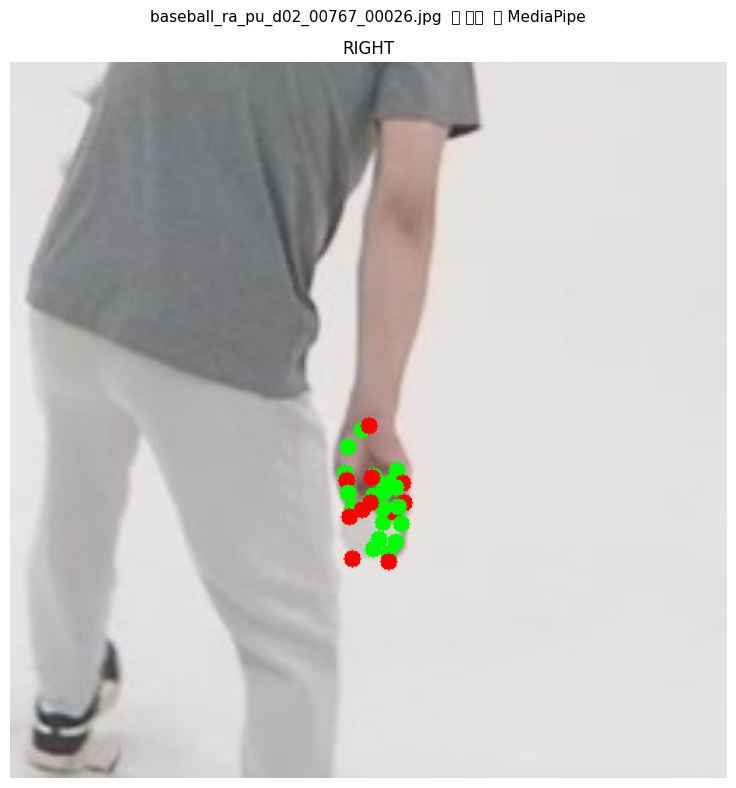

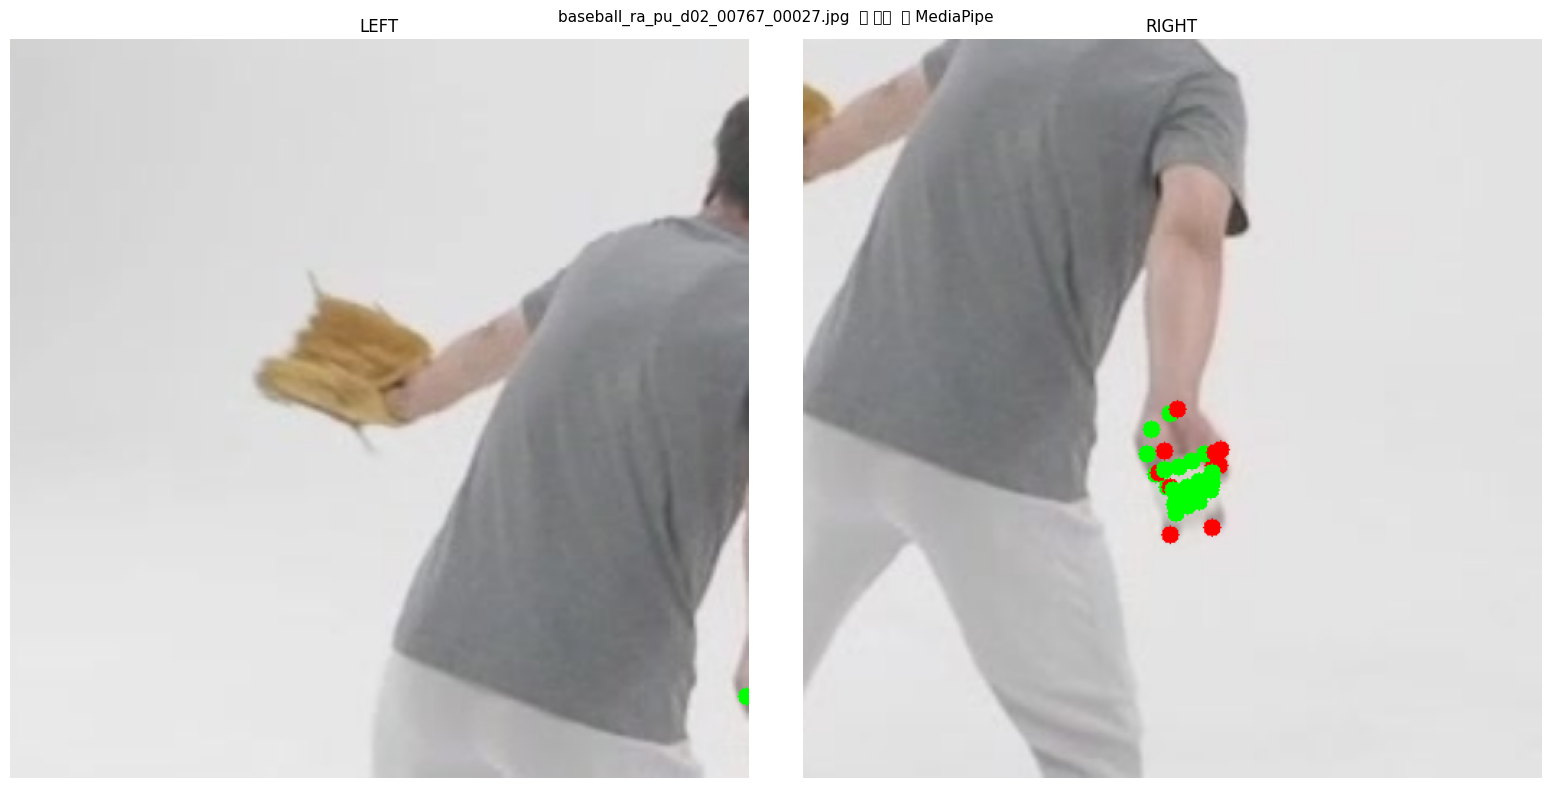

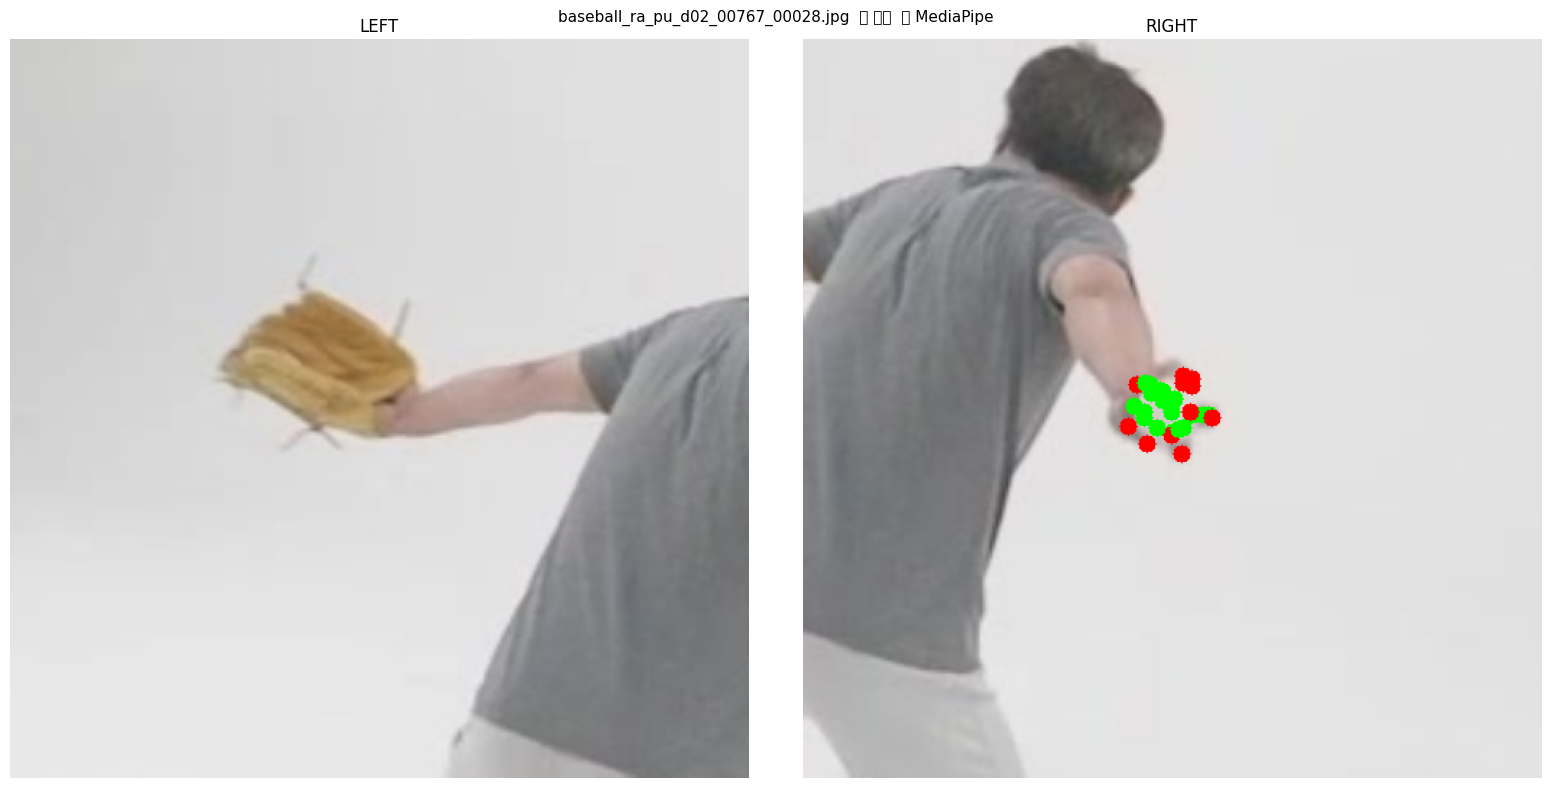

셀 12 완료


In [40]:
# ──────────────────────────────────────────────
# crop 이미지 안에
# 🔴 라벨 좌표 (원본 픽셀 → crop 좌표로 역변환)
# 🟢 MediaPipe 좌표
# 동시 표시 (매칭된 이미지만)
# ──────────────────────────────────────────────

def visualize_crop_comparison(image_name, df_label, df_mp, pose_det, hand_det, padding=0.7):
    img_path = next((p for p in image_paths if Path(p).name == image_name), None)
    if img_path is None:
        print(f"이미지 없음: {image_name}")
        return

    img_bgr = cv2.imread(img_path)
    H, W = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    pose_result = pose_det.process(img_rgb)
    if not pose_result.pose_landmarks:
        print("Pose 감지 실패")
        return

    lms    = pose_result.pose_landmarks.landmark
    row_lb = df_label[df_label["image_name"] == image_name]
    row_mp = df_mp[df_mp["image_name"] == image_name]
    result_crops = []

    for wrist_id in [PoseLandmark.LEFT_WRIST, PoseLandmark.RIGHT_WRIST]:
        wrist = lms[wrist_id]
        label = "LEFT" if wrist_id == PoseLandmark.LEFT_WRIST else "RIGHT"
        if wrist.visibility < 0.3:
            continue

        cx, cy = int(wrist.x * W), int(wrist.y * H)
        pad = int(H * 0.15 * padding)
        x1, y1 = max(0, cx-pad), max(0, cy-pad)
        x2, y2 = min(W, cx+pad), min(H, cy+pad)

        crop = img_bgr[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        crop_h, crop_w = crop.shape[:2]
        crop_draw = cv2.cvtColor(cv2.resize(crop, (512, 512)), cv2.COLOR_BGR2RGB).copy()
        scale_x = 512 / crop_w
        scale_y = 512 / crop_h

        for lm_name in LANDMARKS:
            # 🟢 MediaPipe: crop 내 정규화 좌표
            mp_xcol = f"{lm_name}_x_mp"
            mp_ycol = f"{lm_name}_y_mp"
            if mp_xcol in row_mp.columns:
                mx = row_mp[mp_xcol].values[0]
                my = row_mp[mp_ycol].values[0]
                if pd.notna(mx) and pd.notna(my):
                    # 원본 픽셀 → crop 내 좌표 → 512 스케일
                    px = int((mx - x1) * scale_x)
                    py = int((my - y1) * scale_y)
                    if 0 <= px < 512 and 0 <= py < 512:
                        cv2.circle(crop_draw, (px, py), 6, (0, 255, 0), -1)

            # 🔴 라벨: 원본 픽셀 좌표
            lb_xcol = f"{lm_name}_x"
            lb_ycol = f"{lm_name}_y"
            if lb_xcol in row_lb.columns:
                lx = row_lb[lb_xcol].values[0]
                ly = row_lb[lb_ycol].values[0]
                if pd.notna(lx) and pd.notna(ly):
                    px = int((lx - x1) * scale_x)
                    py = int((ly - y1) * scale_y)
                    if 0 <= px < 512 and 0 <= py < 512:
                        cv2.circle(crop_draw, (px, py), 6, (255, 0, 0), -1)

        result_crops.append((label, crop_draw))

    if not result_crops:
        print("손목 가시성 낮아 crop 없음")
        return

    fig, axes = plt.subplots(1, len(result_crops), figsize=(8 * len(result_crops), 8))
    if len(result_crops) == 1:
        axes = [axes]
    for ax, (title, crop_draw) in zip(axes, result_crops):
        ax.imshow(crop_draw)
        ax.set_title(title, fontsize=12)
        ax.axis("off")
    plt.suptitle(f"{image_name}  🔴 라벨  🟢 MediaPipe", fontsize=11)
    plt.tight_layout()
    plt.show()

# 매칭된 이미지만 순서대로 확인
for name in df_merged["image_name"].values[:3]:
    visualize_crop_comparison(name, df_label, df_mp_wide_renamed, pose_detector, hands_detector)



print("셀 12 완료")